In [1]:
from shap_rscu import load_and_preprocess_data, analyze_codon_shap_trends, codon_trajectory_plot_grid, \
compute_rscu_shap_correlations, get_codon_type, volcano_plot_grid, codon_category_map
import pandas as pd
import numpy as np

In [2]:
segments=["01_PB2", "02_PB1", "03_PA", "04_HA", "05_NP", "06_NA", "07_MP", "08_NS"]

In [3]:
corr_dfs = {}
trend_dfs = {}
for seg in segments:
    print("="*50)
    print(f"Processing segment {seg}")
    print("="*50)

    shap_df_post2020, rscu_df_post2020, codon_cols  = load_and_preprocess_data(seg, data_path='/home/hnguyen/Documents/PhD/Part2/Paper_02_Preparation/data/section3_4_5', file_pattern_shap ='All_True_Label_Post2020_', file_pattern_rscu ='All_True_Label_Post2020_', datatype= 'post2020', verbose=True)
    np.testing.assert_array_equal(shap_df_post2020['seq_ID'].to_numpy(), rscu_df_post2020['seq_ID'].to_numpy())
    shap_df_pre2020,  rscu_df_pre2020, _            = load_and_preprocess_data(seg, data_path='/home/hnguyen/Documents/PhD/Part2/Paper_02_Preparation/data/section3_4_5', file_pattern_shap ='All_True_Label_Training_', file_pattern_rscu ='All_True_Label_Training_', datatype= 'pre2020', verbose=True)
    np.testing.assert_array_equal(shap_df_pre2020['seq_ID'].to_numpy(), rscu_df_pre2020['seq_ID'].to_numpy())
    shap_df_H5Nx, rscu_df_H5Nx, _                   = load_and_preprocess_data(seg, data_path='/home/hnguyen/Documents/PhD/Part2/Paper_02_Preparation/data/section3_4_5/H5Nx_Codon_Shap', file_pattern_shap ='H5Nx_', file_pattern_rscu ='H5Nx_', datatype= 'post2020', verbose=True)
    np.testing.assert_array_equal(shap_df_H5Nx.columns.to_numpy(), shap_df_post2020.columns.to_numpy())
    codon_categories = codon_category_map(codon_cols)
    
    shap_df = pd.concat([shap_df_pre2020, shap_df_post2020, shap_df_H5Nx], ignore_index=True)
    rscu_df = pd.concat([rscu_df_pre2020, rscu_df_post2020, rscu_df_H5Nx], ignore_index=True)

    #shap_df = shap_df[~shap_df['subtype'].isin(['H1N1', 'H3N2'])]
    #rscu_df = rscu_df[~rscu_df['subtype'].isin(['H1N1', 'H3N2'])]
    print (shap_df.shape, rscu_df.shape)
    
    corr_df = compute_rscu_shap_correlations(shap_df, rscu_df, codon_cols, codon_categories, method='spearman')
    corr_df.to_csv(f'../../results/Spearman/{seg}_corr_df_spearman.csv')
    corr_dfs[seg]= corr_df

    trend_df = analyze_codon_shap_trends(shap_df, codon_cols, codon_categories)
    trend_df.to_csv(f'../../results/Spearman/{seg}_trend_df.csv')
    trend_dfs[seg] = trend_df
    #skewness_analysis(shap_df, codon_cols)

Processing segment 01_PB2
Combined SHAP shape: (833250, 66)
Combined RSCU shape: (833250, 66)
Cleaned SHAP shape: (83325, 65)
Cleaned RSCU shape: (83325, 65)

Sequence Count by Subtype & Host Group:
host_group  Avian  Human  Non-human Mammal  Total
subtype                                          
H3N2           33  38365               633  39031
H1N1           58  35179               679  35916
H5N1         4350     27                86   4463
H5N8         1109      0                 1   1110
H1N2           13     20               605    638
H9N2          463     23                 0    486
H3N8          269      8                18    295
H5N6          121     13                 1    135
H5N5          119      0                 7    126
H4N6          115      0                 0    115
H7N3           82      0                 0     82
H3              2     63                 0     65
H6N6           55      0                 0     55
H6N2           51      0                 1     52
H

In [4]:
# codon_categories = codon_category_map(codon_cols)

[('01_PB2', 'Avian'), ('01_PB2', 'Non-human Mammal'), ('01_PB2', 'Human'), ('04_HA', 'Avian'), ('04_HA', 'Non-human Mammal'), ('04_HA', 'Human')]
0 01_PB2 Avian
1 01_PB2 Non-human Mammal
2 01_PB2 Human
3 04_HA Avian
4 04_HA Non-human Mammal
5 04_HA Human


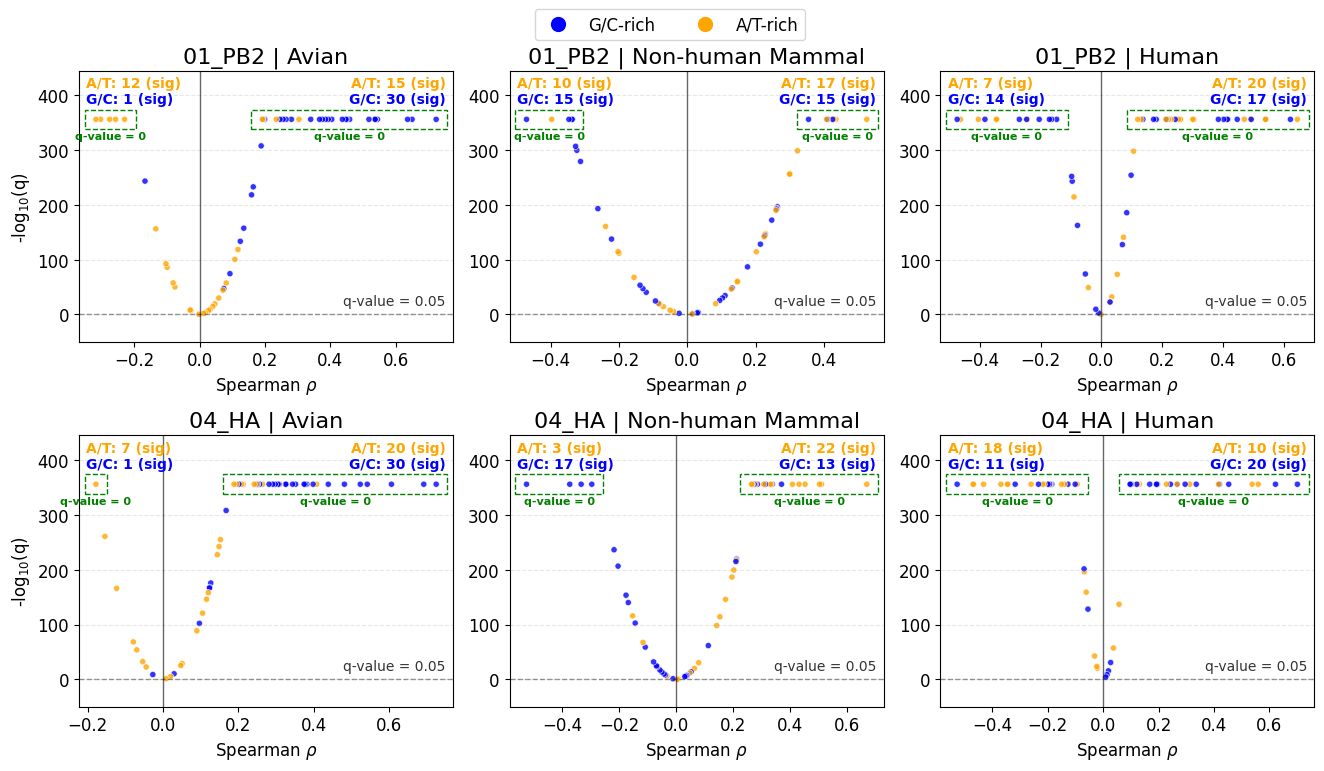

In [5]:
volcano_plot_grid(corr_dfs, codon_categories, save_path="../../results/Figure_5_RSCU_SHAP_Spearman_All_Subtype.png", segments=["01_PB2", "04_HA"], grid_shape=(2, 3), count_significant_only=True)

[('02_PB1', 'Avian'), ('02_PB1', 'Non-human Mammal'), ('02_PB1', 'Human'), ('03_PA', 'Avian'), ('03_PA', 'Non-human Mammal'), ('03_PA', 'Human'), ('05_NP', 'Avian'), ('05_NP', 'Non-human Mammal'), ('05_NP', 'Human'), ('06_NA', 'Avian'), ('06_NA', 'Non-human Mammal'), ('06_NA', 'Human'), ('07_MP', 'Avian'), ('07_MP', 'Non-human Mammal'), ('07_MP', 'Human'), ('08_NS', 'Avian'), ('08_NS', 'Non-human Mammal'), ('08_NS', 'Human')]
0 02_PB1 Avian
1 02_PB1 Non-human Mammal
2 02_PB1 Human
3 03_PA Avian
4 03_PA Non-human Mammal
5 03_PA Human
6 05_NP Avian
7 05_NP Non-human Mammal
8 05_NP Human
9 06_NA Avian
10 06_NA Non-human Mammal
11 06_NA Human
12 07_MP Avian
13 07_MP Non-human Mammal
14 07_MP Human
15 08_NS Avian
16 08_NS Non-human Mammal
17 08_NS Human


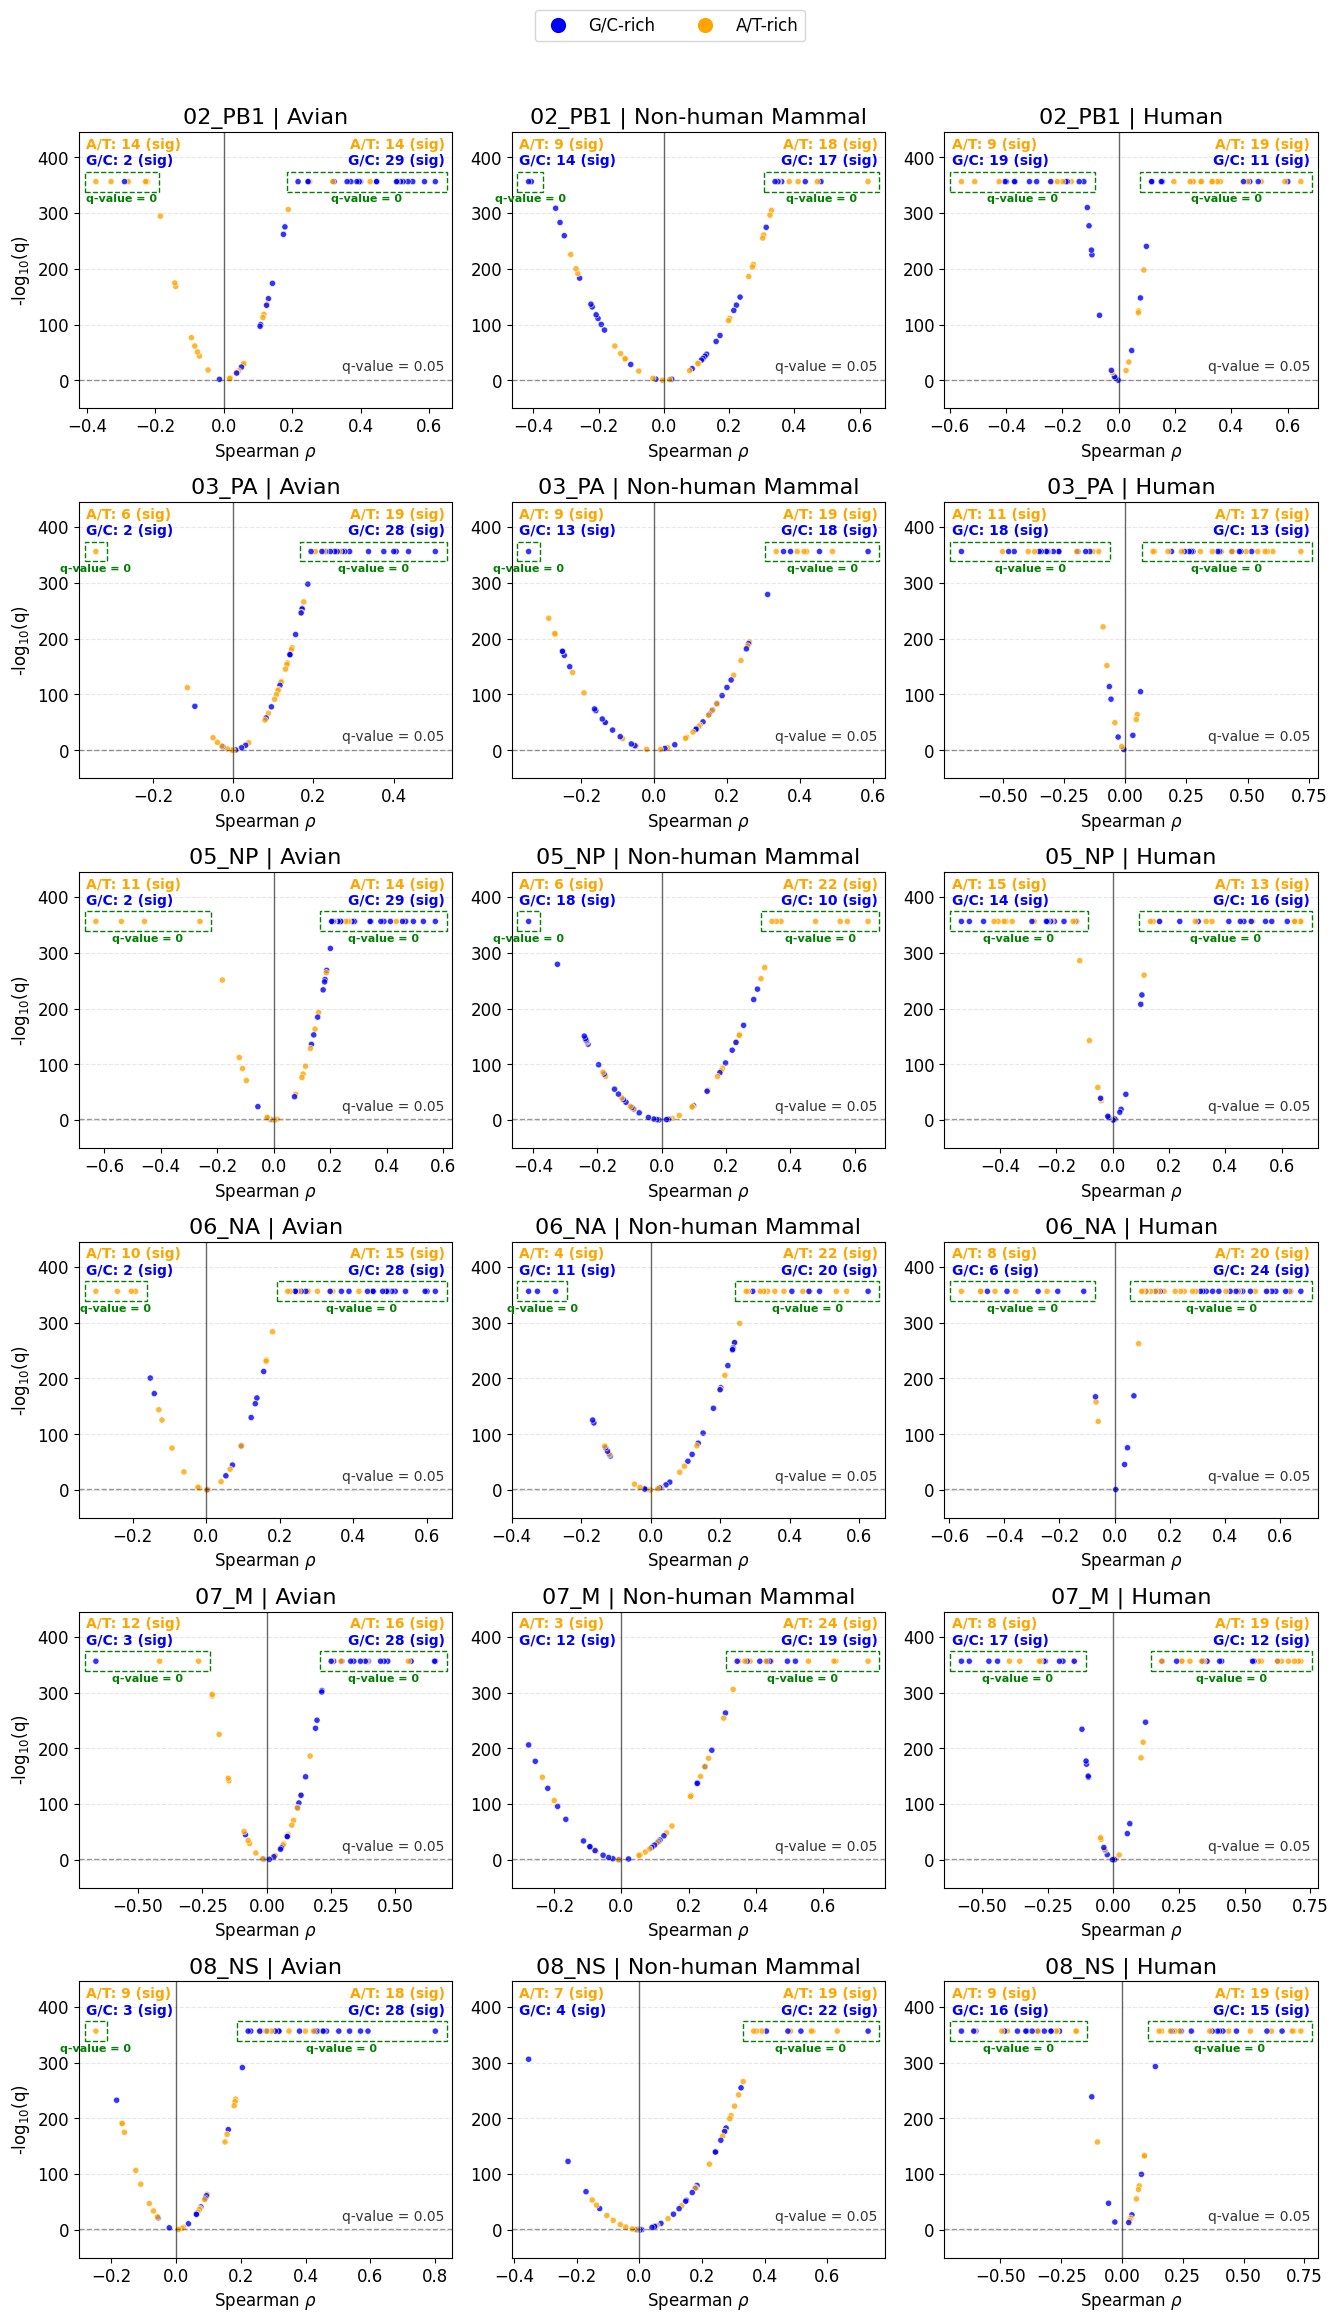

In [6]:
volcano_plot_grid(corr_dfs, codon_categories, save_path="../../results/Supplementary_Figure_S8_RSCU_SHAP_Spearman_All_Subtype.png", segments=["02_PB1", "03_PA", "05_NP", "06_NA", "07_MP", "08_NS"], grid_shape=(6, 3), count_significant_only=True)

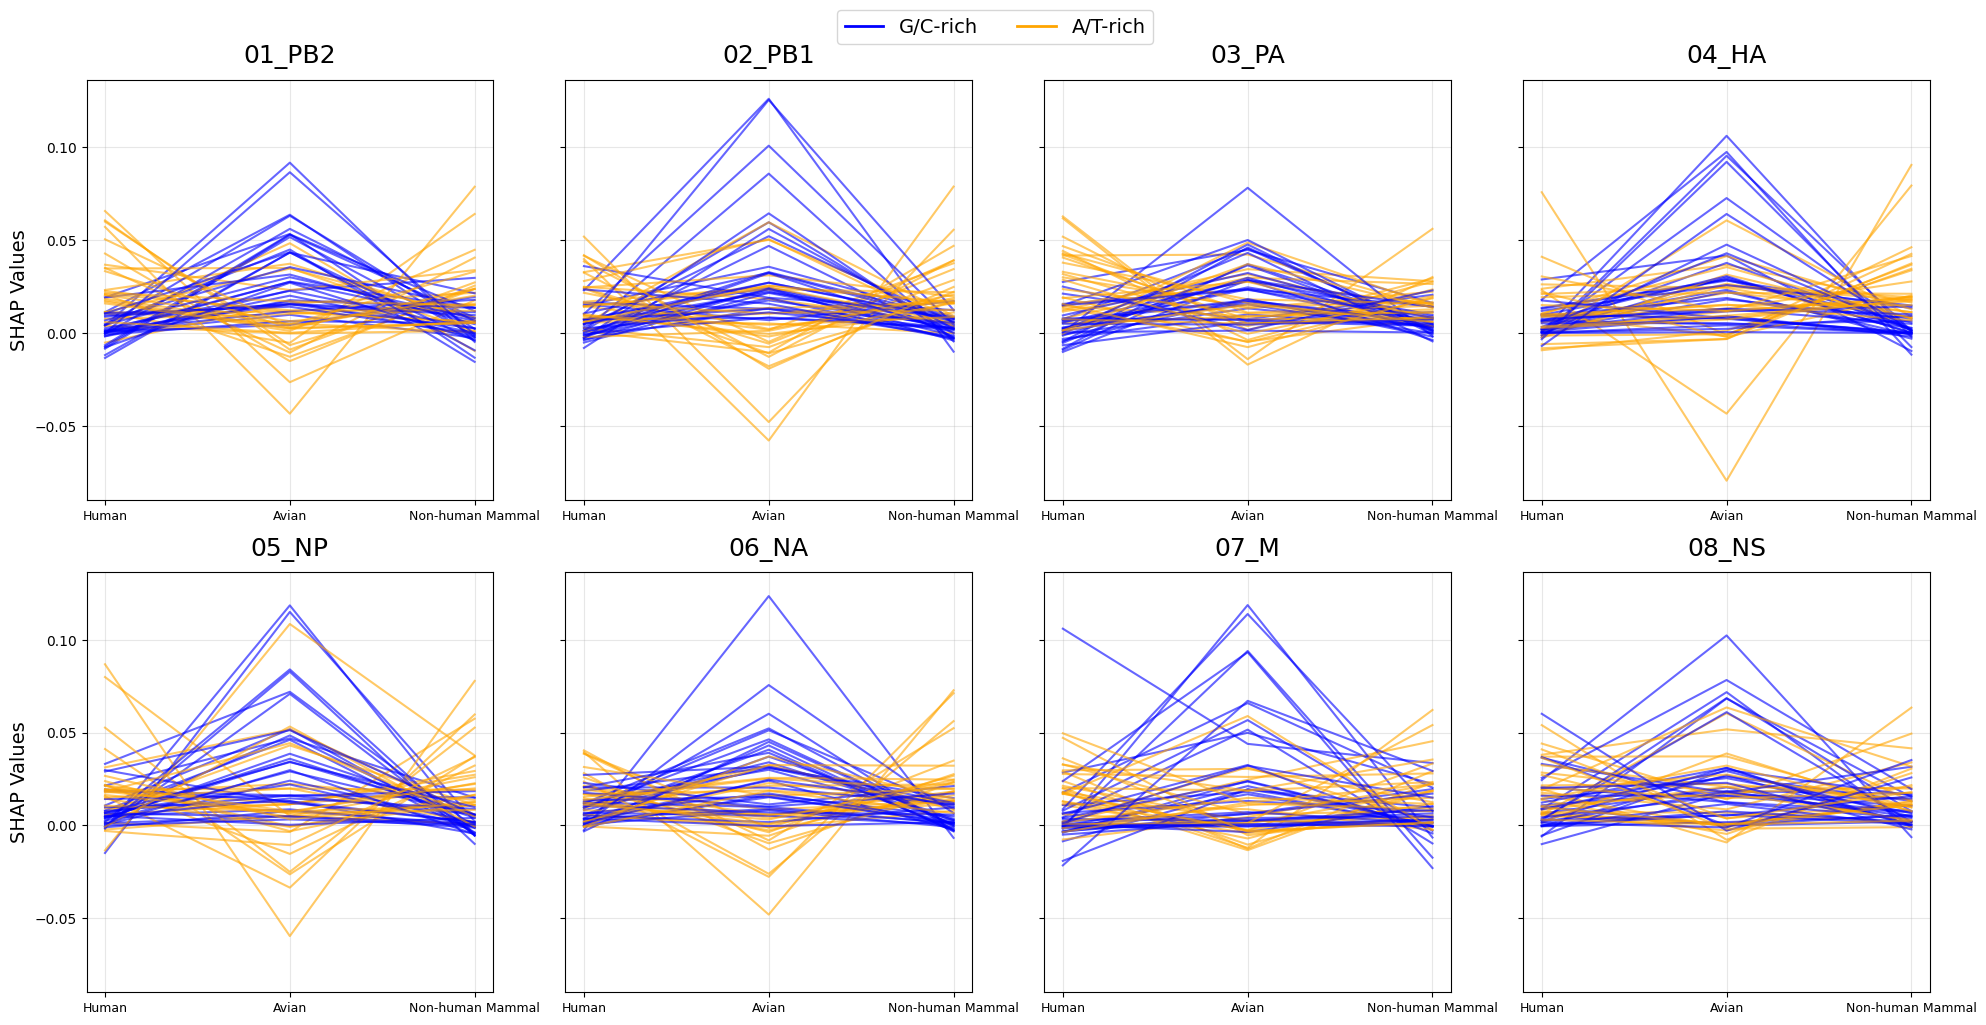

In [7]:
codon_trajectory_plot_grid(trend_dfs, codon_categories, save_path="../../results/Figure_6_Trajectories_All_Subtype.png")